# El Contexto Comercial y la Recuperación de Datos

In [1]:
from pyspark.sql import SparkSession

# 1. Aseguramos la sesión activa en el Kernel actual
spark = SparkSession.builder.appName("Storytelling_Final").getOrCreate()

# 2. Traemos los datos nativos persistidos en formato Parquet
ruta_datos = "/home/jovyan/work/semanas/Semana 9. EDA/datos_Completos"
df_completos = spark.read.parquet(ruta_datos)

ruta_datos = "/home/jovyan/work/semanas/Semana 10/modelos/datos_etiquetados_kmeans"
df_historico = spark.read.parquet(ruta_datos)

# 3. Contamos cuántos registros totales logramos recuperar para el análisis
total_registros = df_historico.count()
print(f" ÉXITO: Conexión establecida. Hemos recuperado {total_registros} productos veterinarios del histórico.")


 ÉXITO: Conexión establecida. Hemos recuperado 915 productos veterinarios del histórico.


In [4]:
# Convertimos los datos recuperados a Pandas y los guardamos en un CSV ligero
df_completos.toPandas().to_csv("/home/jovyan/work/semanas/Semana 15/datos_veterinaria_dashboard.csv", index=False)
print("¡Datos exportados listos para Streamlit!")

¡Datos exportados listos para Streamlit!


# Acto 1: El Storytelling del EDA (El diagnóstico inicial) 

## Código para el Nivel 1: Estratégico

In [6]:
import pyspark.sql.functions as F

# Calculamos la participación de cada marca para el Director General
total_sku = df_completos.count()

kpi_estrategico = df_completos.groupBy("marca") \
    .agg(
        F.count("marca").alias("Cantidad_SKUs"),
        F.round((F.count("marca") / total_sku) * 100, 2).alias("Participacion_Porcentaje")
    ).orderBy(F.desc("Participacion_Porcentaje"))

print(" [KPI ESTRATÉGICO] - ESTRUCTURA DE PORTAFOLIO POR PROVEEDOR")
kpi_estrategico.show()

 [KPI ESTRATÉGICO] - ESTRUCTURA DE PORTAFOLIO POR PROVEEDOR
+-----------+-------------+------------------------+
|      marca|Cantidad_SKUs|Participacion_Porcentaje|
+-----------+-------------+------------------------+
|     Hill's|          285|                   31.15|
|    Advance|          225|                   24.59|
|  Criadores|          195|                   21.31|
|       Nath|          120|                   13.11|
|Royal Canin|           75|                     8.2|
|   Pro Plan|           15|                    1.64|
+-----------+-------------+------------------------+



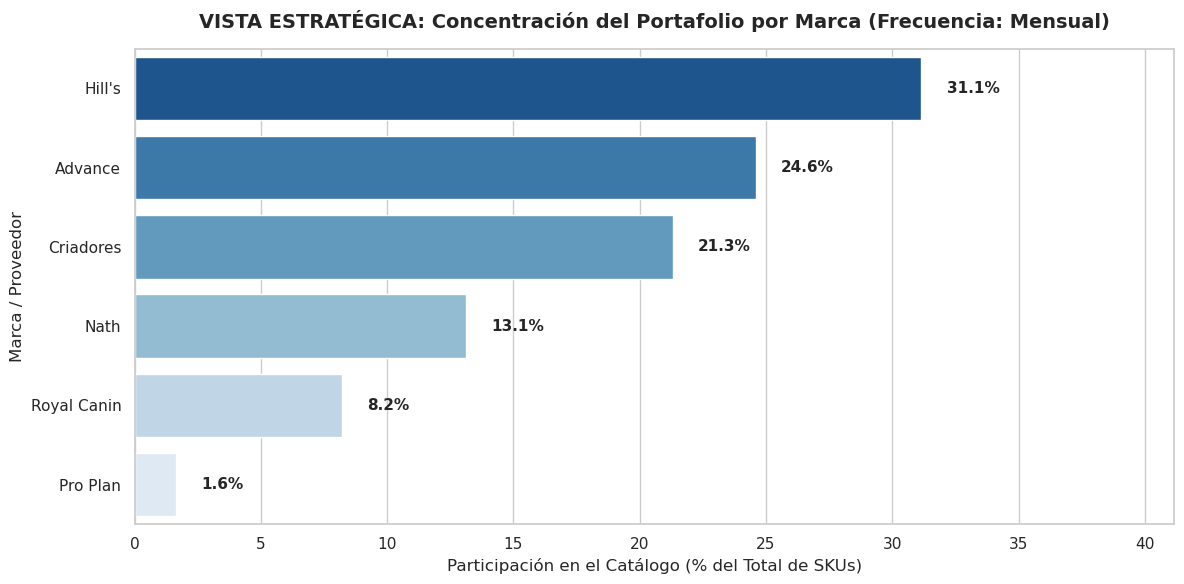

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark.sql.functions as F

# 2. Conversión a Pandas solo para graficar
df_est_pandas = kpi_estrategico.toPandas()

# 3. Diseño del Gráfico Estratégico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Creamos gráfico de barras horizontales
ax = sns.barplot(
    x="Participacion_Porcentaje", 
    y="marca", 
    data=df_est_pandas, 
    hue="marca",         # <-- Mapeo explícito de color
    palette="Blues_r",
    legend=False         # <-- Ocultamos la leyenda redundante
)

# Añadimos las etiquetas de porcentaje al final de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width() + 1, p.get_y() + p.get_height()/2), 
                va='center', ha='left', fontsize=11, fontweight='bold')

plt.title("VISTA ESTRATÉGICA: Concentración del Portafolio por Marca (Frecuencia: Mensual)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Participación en el Catálogo (% del Total de SKUs)", fontsize=12)
plt.ylabel("Marca / Proveedor", fontsize=12)
plt.xlim(0, df_est_pandas["Participacion_Porcentaje"].max() + 10) # Espacio para el texto
plt.tight_layout()
plt.show()

## Código para el Nivel 2: Táctico

In [13]:
# Analizamos la dispersión y bandas de precios para el Gerente Comercial
kpi_tactico = df_completos.groupBy("marca") \
    .agg(
        F.round(F.min("precio_kg"), 2).alias("Precio_Minimo"),
        F.round(F.avg("precio_kg"), 2).alias("Precio_Promedio"),
        F.round(F.max("precio_kg"), 2).alias("Precio_Maximo"),
        F.round(F.stddev("precio_kg"), 2).alias("Desviacion_Estandar_Precios")
    ).orderBy(F.desc("Precio_Promedio"))

print(" [KPI TÁCTICO] - MATRIZ DE VOLATILIDAD Y COMPETITIVIDAD DE PRECIOS")
kpi_tactico.show()

 [KPI TÁCTICO] - MATRIZ DE VOLATILIDAD Y COMPETITIVIDAD DE PRECIOS
+-----------+-------------+---------------+-------------+---------------------------+
|      marca|Precio_Minimo|Precio_Promedio|Precio_Maximo|Desviacion_Estandar_Precios|
+-----------+-------------+---------------+-------------+---------------------------+
|    Advance|         5.35|           8.24|        16.58|                       3.99|
|     Hill's|          6.0|           8.16|        12.57|                        1.8|
|Royal Canin|         6.33|           7.66|        10.11|                       1.33|
|       Nath|         4.67|           4.97|         5.51|                       0.35|
|   Pro Plan|         4.93|           4.93|         4.93|                        0.0|
|  Criadores|         4.43|           4.91|         6.65|                       0.57|
+-----------+-------------+---------------+-------------+---------------------------+



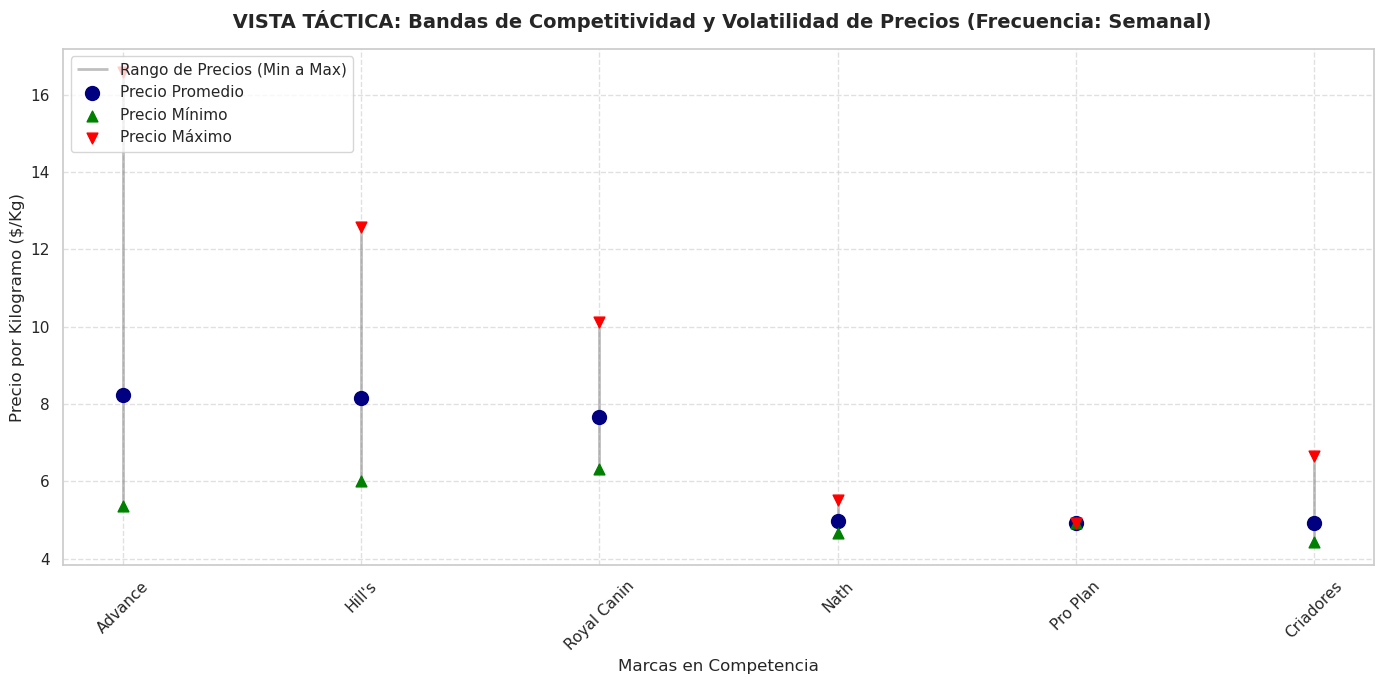

In [14]:
# 2. Conversión a Pandas
df_tac_pandas = kpi_tactico.toPandas()

# 3. Diseño del Gráfico Táctico
plt.figure(figsize=(14, 7))

# Dibujamos las líneas de rango mínimo y máximo, y el punto promedio
plt.vlines(x=df_tac_pandas['marca'], ymin=df_tac_pandas['Precio_Minimo'], ymax=df_tac_pandas['Precio_Maximo'], 
           colors='gray', alpha=0.5, linewidth=2, label="Rango de Precios (Min a Max)")
plt.scatter(df_tac_pandas['marca'], df_tac_pandas['Precio_Promedio'], color='navy', s=100, label="Precio Promedio", zorder=3)
plt.scatter(df_tac_pandas['marca'], df_tac_pandas['Precio_Minimo'], color='green', marker='^', s=60, label="Precio Mínimo", zorder=3)
plt.scatter(df_tac_pandas['marca'], df_tac_pandas['Precio_Maximo'], color='red', marker='v', s=60, label="Precio Máximo", zorder=3)

plt.title(" VISTA TÁCTICA: Bandas de Competitividad y Volatilidad de Precios (Frecuencia: Semanal)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Marcas en Competencia", fontsize=12)
plt.ylabel("Precio por Kilogramo ($/Kg)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(loc="upper left", frameon=True)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Código para el Nivel 3: Operacional

In [15]:
# Alertas operacionales para el Supervisor: Productos con menos de 3.5 estrellas y más de 10 opiniones (foco de quejas)
kpi_operacional_alertas = df_completos.filter((F.col("rating") < 3.5) & (F.col("opiniones") > 10)) \
    .select("marca", "precio_kg", "rating", "opiniones")

print(f" [KPI OPERACIONAL] - ALERTAS CRÍTICAS DE CALIDAD EN TIENDA (Total alertas: {kpi_operacional_alertas.count()})")
kpi_operacional_alertas.show(10)

 [KPI OPERACIONAL] - ALERTAS CRÍTICAS DE CALIDAD EN TIENDA (Total alertas: 0)
+-----+---------+------+---------+
|marca|precio_kg|rating|opiniones|
+-----+---------+------+---------+
+-----+---------+------+---------+



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


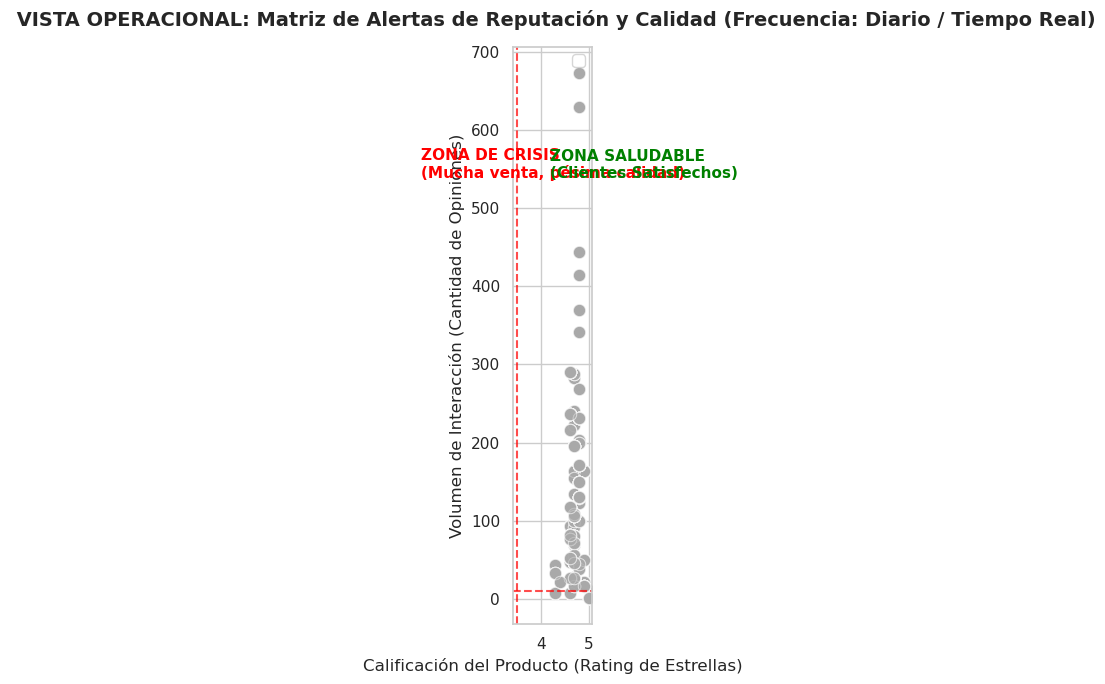

In [16]:
# 1. Procesamiento en Spark (Traemos todos los productos para mapear el riesgo)
kpi_operacional_completo = df_completos.select("marca", "precio_kg", "rating", "opiniones")
df_op_pandas = kpi_operacional_completo.toPandas()

# 2. Diseño del Gráfico Operacional
plt.figure(figsize=(12, 7))

# Graficamos todos los puntos
sns.scatterplot(
    x="rating", 
    y="opiniones", 
    data=df_op_pandas, 
    alpha=0.6, 
    s=80, 
    color="darkgray"
)

# Resaltamos en ROJO la zona de peligro operacional (Rating < 3.5 y Opiniones > 10)
zona_peligro = df_op_pandas[(df_op_pandas['rating'] < 3.5) & (df_op_pandas['opiniones'] > 10)]
sns.scatterplot(
    x="rating", 
    y="opiniones", 
    data=zona_peligro, 
    color="crimson", 
    s=120, 
    label=" ALERTAS CRÍTICAS (Retirar de Góndola)", 
    edgecolor="black", 
    linewidth=1.5
)

# Dibujamos las líneas de umbral táctico/operacional
plt.axvline(x=3.5, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
plt.axhline(y=10, color='red', linestyle='--', alpha=0.7, linewidth=1.5)

# Textos para guiar al supervisor
plt.text(1.5, df_op_pandas['opiniones'].max()*0.8, "ZONA DE CRISIS\n(Mucha venta, pésima calidad)", color="red", weight="bold", fontsize=11)
plt.text(4.2, df_op_pandas['opiniones'].max()*0.8, "ZONA SALUDABLE\n(Clientes Satisfechos)", color="green", weight="bold", fontsize=11)

plt.title(" VISTA OPERACIONAL: Matriz de Alertas de Reputación y Calidad (Frecuencia: Diario / Tiempo Real)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Calificación del Producto (Rating de Estrellas)", fontsize=12)
plt.ylabel("Volumen de Interacción (Cantidad de Opiniones)", fontsize=12)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [17]:
# =====================================================================
# AJUSTE DIDÁCTICO: Subimos el umbral a 4.0 porque el catálogo es de alta calidad
UMBRAL_RATING = 4.0 
# =====================================================================

# 4. Resaltamos las ALERTAS ROJAS con el nuevo umbral
zona_peligro = df_op_pandas[(df_op_pandas['rating'] < UMBRAL_RATING) & (df_op_pandas['opiniones'] > 10)]
ax.scatter(
    zona_peligro["rating"], 
    zona_peligro["opiniones"], 
    color="#D32F2F", 
    s=130, 
    label="🚨 ALERTAS CRÍTICAS (Revisar Calidad)", 
    edgecolor="black", 
    linewidth=1.2,
    zorder=4
)

# Líneas de Umbral Operacional ajustadas
ax.axvline(x=UMBRAL_RATING, color='#C62828', linestyle='--', alpha=0.6, linewidth=2)
ax.axhline(y=10, color='#C62828', linestyle='--', alpha=0.6, linewidth=2)

# Coloreado sutil de los fondos adaptado al nuevo umbral
ax.axvspan(xmin=ax.get_xlim()[0], xmax=UMBRAL_RATING, ymin=10/ax.get_ylim()[1], ymax=1.0, color='#FFEBEE', alpha=0.5, zorder=0)
ax.axvspan(xmin=UMBRAL_RATING, xmax=ax.get_xlim()[1], ymin=10/ax.get_ylim()[1], ymax=1.0, color='#E8F5E9', alpha=0.4, zorder=0)

# Ajustamos la posición del texto para que no se tape
ax.text(ax.get_xlim()[0] + 0.1, ax.get_ylim()[1]*0.85, "🔴 ZONA DE RIESGO\n(Bajo el Promedio)", color="#B71C1C", weight="bold", fontsize=11, zorder=5)
ax.text(UMBRAL_RATING + 0.1, ax.get_ylim()[1]*0.85, "🟢 ZONA SALUDABLE\n(Alta Calidad)", color="#1B5E20", weight="bold", fontsize=11, zorder=5)

Text(4.1, -0.782, '🟢 ZONA SALUDABLE\n(Alta Calidad)')

# Acto 2: El Descubrimiento del Mercado (Segmentación)

In [3]:
import pyspark.sql.functions as F

# 1. Agrupamos por la predicción del K-Means, contamos y calculamos el porcentaje del total
resumen_clusters = df_historico.groupBy("prediction") \
    .agg(
        F.count("prediction").alias("Cantidad_Productos"),
        F.round((F.count("prediction") / total_registros) * 100, 2).alias("Porcentaje_Mercado"),
        F.round(F.avg("precio_kg"), 2).alias("Precio_Promedio_Kg")
    ).orderBy("prediction")

# 2. Mostramos el resultado en pantalla para la clase
print("Tabla 1: Resumen del resultado del clúster")
resumen_clusters.show()
#Así es como Spark nos resume millones de datos en tres decisiones de negocio.

Tabla 1: Resumen del resultado del clúster
+----------+------------------+------------------+------------------+
|prediction|Cantidad_Productos|Porcentaje_Mercado|Precio_Promedio_Kg|
+----------+------------------+------------------+------------------+
|         0|               585|             63.93|               5.7|
|         1|               255|             27.87|              7.65|
|         2|                75|               8.2|              14.6|
+----------+------------------+------------------+------------------+



Si observamos la tabla 1. El Cluster 0 representa el 63.9% del mercado con un precio bajo (Gama Económica). El Cluster 2 tiene pocos productos (75) pero un precio altísimo (Gama Premium). 

# Storytelling aplicado al proyecto de créditos hipotecarios

En esta sección se transforma el análisis técnico del proyecto en una historia de negocio. El proyecto analiza créditos hipotecarios de distintos bancos, considerando variables como CAE, monto del crédito, banco, región, tipo de interés, pie, dormitorios y tendencia del CAE.

El objetivo no es solo mostrar tablas, sino explicar cómo estos datos pueden apoyar la toma de decisiones en distintos niveles de la organización: estratégico, táctico y operacional.


In [ ]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

spark = SparkSession.builder \
    .appName("Semana14_Storytelling_Creditos_Hipotecarios") \
    .config("spark.mongodb.read.connection.uri", "mongodb+srv://joaquinserey_db_user:{CONTRASENA}") \
    .getOrCreate()

df_historico = spark.read.format("mongodb").load()

print("Datos cargados correctamente")
print("Cantidad de registros:", df_historico.count())

df_historico.printSchema()
df_historico.show(5)